In [56]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.patches import Circle
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
from collections import Counter
from tqdm.notebook import tqdm
from deeptime.clustering import KMeans
from deeptime.clustering import RegularSpace
from deeptime.clustering import BoxDiscretization
import pandas as pd 
import pyemma

import mdtraj as md
import re, math, os, shutil, pickle

import warnings; warnings.simplefilter('ignore')
from collections import Counter

## Important Functions

In [31]:
class Data:
    def __init__(self, array_list):
        self.array_list = array_list

    def save(self, filename):
        with open(filename, 'wb') as f:
            pickle.dump(self.array_list, f)

    @classmethod
    def load(cls, filename):
        with open(filename, 'rb') as f:
            array_list = pickle.load(f)
        return cls(array_list)

## Load the distance data

In [75]:
nstates = 16

dist_all = []
for i in range(nstates):
    dist_path = f"traj_data/dist_state{i}.pkl"
    dist = Data.load(dist_path)
    dist = dist.array_list
    print(f'state {i}: {np.array(dist).shape}')
    dist_all.append(dist)

dist_all = np.array(dist_all)
print('dist_all.shape', dist_all.shape)

omega_all = []
for i in range(nstates):
    omega_path = f"traj_data/omegas_state{i}.pkl"
    omegas = Data.load(omega_path)
    omegas = omegas.array_list
    print(f'state {i}:, {np.array(omegas).shape}')
    omega_all.append(omegas)

omega_all = np.array(omega_all)
omega_all.shape

state 0: (200010, 76)
state 1: (200010, 76)
state 2: (200010, 76)
state 3: (200010, 76)
state 4: (200010, 76)
state 5: (200010, 76)
state 6: (200010, 76)
state 7: (200010, 76)
state 8: (200010, 76)
state 9: (200010, 76)
state 10: (200010, 76)
state 11: (200010, 76)
state 12: (200010, 76)
state 13: (200010, 76)
state 14: (200010, 76)
state 15: (200010, 76)
dist_all.shape (16, 200010, 76)
state 0:, (200010, 24)
state 1:, (200010, 24)
state 2:, (200010, 24)
state 3:, (200010, 24)
state 4:, (200010, 24)
state 5:, (200010, 24)
state 6:, (200010, 24)
state 7:, (200010, 24)
state 8:, (200010, 24)
state 9:, (200010, 24)
state 10:, (200010, 24)
state 11:, (200010, 24)
state 12:, (200010, 24)
state 13:, (200010, 24)
state 14:, (200010, 24)
state 15:, (200010, 24)


(16, 200010, 24)

## Process this into TimeLaggedDataset

In [33]:
from deeptime.util.types import is_timelagged_dataset
from deeptime.util.types import to_dataset

# Convert list of trajectories to a time-lagged dataset
lag = 1
dataset = to_dataset(dist_all, lagtime=lag)

print(len(dataset))         # Should be ~ len(traj) - lagtime * n_states
#print(dataset[0])           # Tuple of (x_t, x_t+lag)
print(dataset[0][0].shape)  # Should be (76,)

# Check if the resulting dataset is a valid time-lagged dataset
print(is_timelagged_dataset(dataset))  # Should return True


3200144
(76,)
True


## TICA

In [34]:
from deeptime.decomposition import TICA
tica = TICA(lagtime=1, dim=2) # create a tica estimator 
tica.fit(dist_all)      # Fit directly from raw trajectories

TICA-6995047760:[{'dim': 2,
                 'epsilon': 1e-06,
                 'lagtime': 1,
                 'observable_transform': <deeptime.basis._monomials.Identity object at 0x196ae1690>,
                 'scaling': 'kinetic_map',
                 'var_cutoff': None}]

In [35]:
# obtain model 
model = tica.fetch_model()
# Create the projection data 
projection = model.transform(dist_all)
print(projection.shape)

(16, 200010, 2)


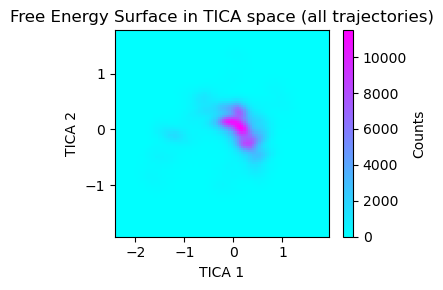

In [36]:
all_proj = np.concatenate(projection, axis=0)

x_all = all_proj[:, 0]  # TICA 1
y_all = all_proj[:, 1]  # TICA 2

# Plot 2D histogram (density map)
plt.figure(figsize=(4, 3))
plt.hist2d(x_all, y_all, bins=100, cmap='cool')
plt.colorbar(label='Counts')
plt.xlabel('TICA 1')
plt.ylabel('TICA 2')
plt.title('Free Energy Surface in TICA space (all trajectories)')
plt.tight_layout()
plt.show()

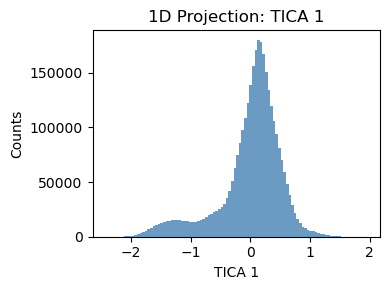

In [37]:
plt.figure(figsize=(4, 3))
plt.hist(x_all, bins=100, color='steelblue', alpha=0.8)
plt.xlabel('TICA 1')
plt.ylabel('Counts')
plt.title('1D Projection: TICA 1')
plt.tight_layout()
plt.show()


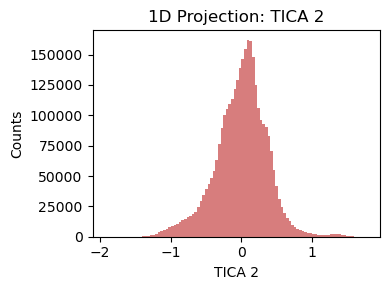

In [38]:
plt.figure(figsize=(4, 3))
plt.hist(y_all, bins=100, color='indianred', alpha=0.8)
plt.xlabel('TICA 2')
plt.ylabel('Counts')
plt.title('1D Projection: TICA 2')
plt.tight_layout()
plt.show()


## Clustering

In [40]:
from deeptime.clustering import MiniBatchKMeans

n_clusters = 100
estimator = KMeans(
    n_clusters=n_clusters,  # number of cluster centers
    max_iter=100,  # maximum number of passes over full dataset when calling fit()
    init_strategy='kmeans++',  # initialization strategy
    fixed_seed=42,
    n_jobs=1
)

In [41]:
clustering_tica = estimator.fit(all_proj).fetch_model()
assignments = clustering_tica.transform(all_proj)
#print(np.unique(assignments)) # Print assignment labels 

# Find the cluster centers
cluster_centers = clustering_tica.cluster_centers

In [82]:
## Calcuate the percentage of each assignments 

# count the number of each cluter 
counts = Counter(assignments)
#print(counts)

# Sort the counts 
sorted_counts = dict(sorted(counts.items()))
total_counts = sum(counts.values())
cluster = []

for label, frequency in sorted_counts.items():    
    precentage = (frequency / total_counts) * 100 
    cluster.append(precentage)
    #print(f"Assignment {label}: {frequency}, {precentage:.4g}%")


# Example input (either form)
# top_n = 10                     # automatic selection
# top_n = [2, 5, 7]              # manual selection
top_n = [0, 95, 23, 54, 10, 88]                  # manually selected cluster 10

# Process top clusters
if isinstance(top_n, int):
    # Automatically choose top-N most populated clusters
    top = sorted(sorted_counts.items(), key=lambda x: x[1], reverse=True)[:top_n]
elif isinstance(top_n, list):
    # Manually specified cluster labels
    top = [(label, sorted_counts[label]) for label in top_n if label in sorted_counts]
else:
    raise ValueError("top_n must be either an int or a list of cluster labels.")



print(f"Top {top_n} most populated clusters:")
for label, count in top:
    percentage = (count / total_counts) * 100
    print(f"Assignment {label}: {count} frames, {percentage:.4g}%")

Top [0, 95, 23, 54, 10, 88] most populated clusters:
Assignment 0: 89717 frames, 2.804%
Assignment 95: 10412 frames, 0.3254%
Assignment 23: 12047 frames, 0.3764%
Assignment 54: 11366 frames, 0.3552%
Assignment 10: 17474 frames, 0.546%
Assignment 88: 13943 frames, 0.4357%


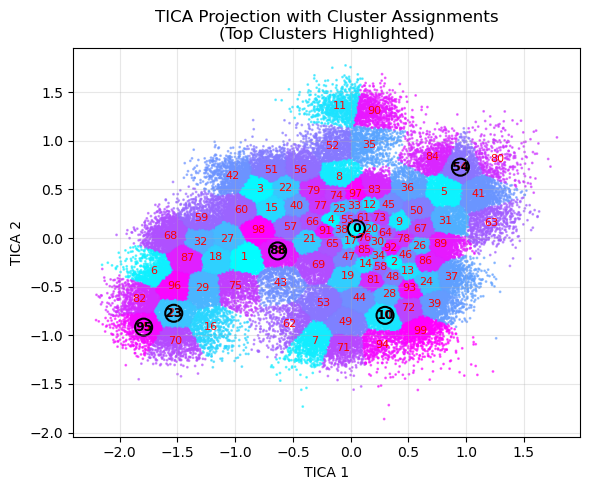

In [83]:
plt.figure(figsize=(6, 5))
stride = 10

# Main scatter: all points colored by assignment
x_sample = all_proj[::stride, 0]
y_sample = all_proj[::stride, 1]
c_sample = assignments[::stride]

plt.scatter(x_sample, y_sample, c=c_sample, cmap='cool', s=1, alpha=0.6)


# Overlay top clusters with larger black circles or special markers
top_labels = [label for label, _ in top]

# Optional: also draw all cluster centers (optional if highlighting top)
for i, (x, y) in enumerate(cluster_centers):
    plt.text(x, y, str(i), fontsize=8, color='red', ha='center', va='center')
    
for label in top_labels:
    # Get center of this cluster
    x, y = cluster_centers[label]

    # Draw a larger, highlighted marker or circle
    plt.scatter(x, y, s=150, edgecolors='black', facecolors='none', linewidths=1.5, marker='o')
    plt.text(x, y, str(label), fontsize=9, color='black', ha='center', va='center', weight='bold')



plt.xlabel("TICA 1")
plt.ylabel("TICA 2")
plt.title("TICA Projection with Cluster Assignments\n(Top Clusters Highlighted)")
plt.tight_layout()
plt.grid(alpha=0.3)
plt.show()


## Analysis the Top Populated Clusters

In [84]:
# Build a list of (traj_index, frame_index) for each row in all_proj
frame_map = []

for traj_idx, traj in enumerate(projection):
    for frame_idx in range(traj.shape[0]):  # shape is (200010, 2)
        frame_map.append((traj_idx, frame_idx))

frame_map = np.array(frame_map)  # shape (3200160, 2)
frame_map.shape

(3200160, 2)

In [85]:
top_cluster_frames = {label: [] for label, _ in top}

for label in top_cluster_frames:
    indices = np.where(assignments == label)[0]  # flattened indices
    traj_frame_pairs = frame_map[indices]  # shape (N, 2)  (traj_index, frame_index)
    top_cluster_frames[label] = traj_frame_pairs

    print(f"Cluster {label}: {traj_frame_pairs.shape[0]} frames")


Cluster 0: 89717 frames
Cluster 95: 10412 frames
Cluster 23: 12047 frames
Cluster 54: 11366 frames
Cluster 10: 17474 frames
Cluster 88: 13943 frames


In [86]:
top_labels = [label for label, _ in top]
print('top_labels', top_labels)
label = top_labels[0]
for traj_idx, frame_idx in top_cluster_frames[label][:5]:  # show 5 examples
    original_frame = dist_all[traj_idx][frame_idx]  # shape (76,)
    print(f"Cluster {label} → traj {traj_idx}, frame {frame_idx}, feature shape: {original_frame.shape}")


top_labels [0, 95, 23, 54, 10, 88]
Cluster 0 → traj 0, frame 1006, feature shape: (76,)
Cluster 0 → traj 0, frame 1102, feature shape: (76,)
Cluster 0 → traj 0, frame 1259, feature shape: (76,)
Cluster 0 → traj 0, frame 1278, feature shape: (76,)
Cluster 0 → traj 0, frame 1542, feature shape: (76,)


### Distance analysis

In [87]:
restraints_table = {
    'weak': 5,
    'medium': 3.5,
    'strong': 2.5
}

dist_res_file = '../../../utils/nspe_7_1_restraints.csv'
df_dist_res = pd.read_csv(dist_res_file)

for i, row in df_dist_res.iterrows():
    df_dist_res.at[i, df_dist_res.columns[2]] = restraints_table[row[2]]  # Correct mapping

# Make a look up table for intensity 
df_dist_res
dist_res = df_dist_res.values.tolist()
dist_res[:5]

[[160, 165, 5], [160, 166, 5], [161, 165, 5], [161, 166, 5], [137, 165, 5]]

In [88]:
atomtype_lookup = {
    ('H02', 'H12'): 'α11',
    ('H02', 'H13'): 'α11',
    ('H02', 'H3'): 'α2',
    ('H02', 'H4'): 'β3',
    ('H02', 'H5'): 'β3',
    ('H02', 'H6'): 'β3',
    ('R02', 'H10'): 'α11',
    ('R02', 'H11'): 'α11',
    ('R02', 'H1'): 'α2',
    ('R02', 'H2'): 'β3',
    ('R02', 'H3'): 'β3',
    ('R02', 'H4'): 'β3',
    ('NH2', 'HN1'): 'NH1',
    ('NH2', 'HN2'): 'NH1',
}


In [89]:
def translate_pyemma_label(label):
    # Remove 'DIST: ' prefix and whitespace
    label = label.replace('DIST: ', '').strip()
    
    # Split into two atoms
    part1, part2 = label.split(' - ')
    resname1, resid1, atomname1, atomid1 = part1.split()
    resname2, resid2, atomname2, atomid2 = part2.split()

    # Lookup group for each atom
    group1 = atomtype_lookup.get((resname1, atomname1), 'unknown')
    group2 = atomtype_lookup.get((resname2, atomname2), 'unknown')

    # Print (optional)
    print(f"Label: {label}")
    print(f"Residue 1: {resname1} {resid1}, Atom: {atomname1} ({atomid1}), Group: {group1}")
    print(f"Residue 2: {resname2} {resid2}, Atom: {atomname2} ({atomid2}), Group: {group2}")

    # Return formatted result
    return f"{resid1}{group1}-{resid2}{group2}"


In [90]:
# Settings
human_interpretable_label = True
grofile = "../nspe_7_1.amb2gmx/nspe_7_1_GMX.gro"

# Prepare label cache
labels = []
targets = []

for atom1, atom2, target in dist_res:
    targets.append(target)

    atom1_pyemma = atom1 - 1
    atom2_pyemma = atom2 - 1
    feat = pyemma.coordinates.featurizer(grofile)
    feat.add_distances([[atom1_pyemma, atom2_pyemma]])
    raw_label = feat.describe()[0]

    if human_interpretable_label:
        label = translate_pyemma_label(label=raw_label)
    else:
        label = raw_label

    labels.append(label)

targets = np.array(targets)
labels[1]


Label: R02 7 H10 159 - NH2 8 HN1 164
Residue 1: R02 7, Atom: H10 (159), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 7 H10 159 - NH2 8 HN2 165
Residue 1: R02 7, Atom: H10 (159), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
Label: R02 7 H11 160 - NH2 8 HN1 164
Residue 1: R02 7, Atom: H11 (160), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 7 H11 160 - NH2 8 HN2 165
Residue 1: R02 7, Atom: H11 (160), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
Label: R02 6 H10 136 - NH2 8 HN1 164
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 6 H10 136 - NH2 8 HN2 165
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
Label: R02 6 H11 137 - NH2 8 HN1 164
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 6 H11 137 - NH2 8 HN2 165
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue 2: NH2

'7α11-8NH1'

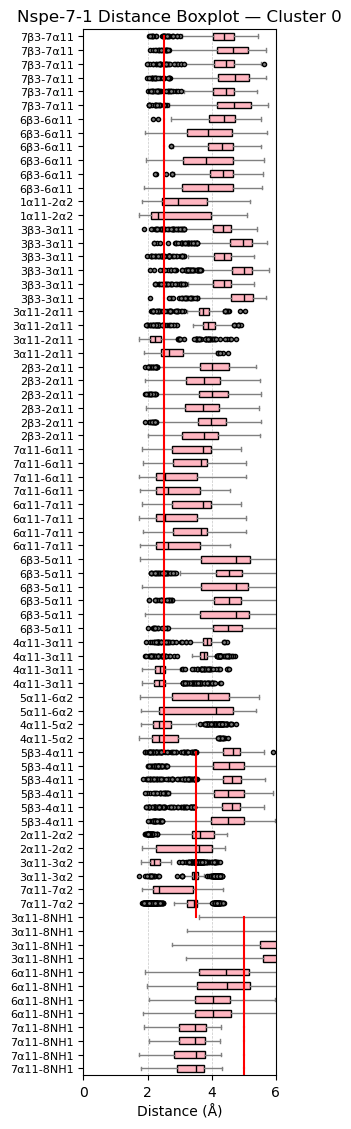

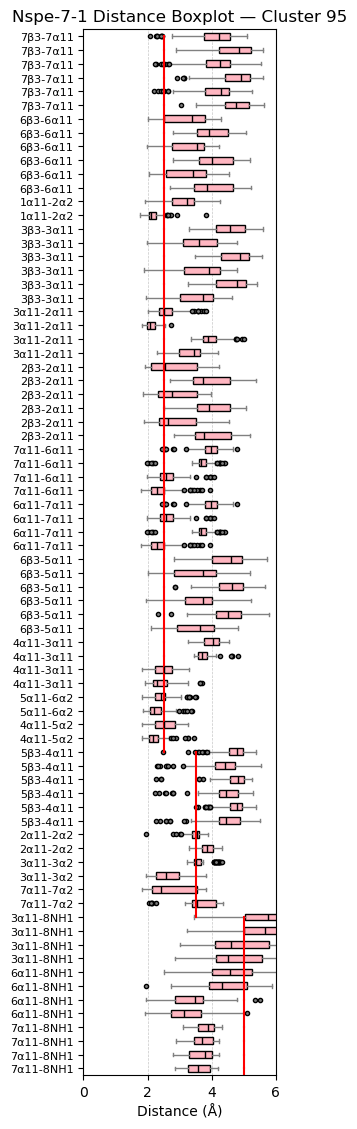

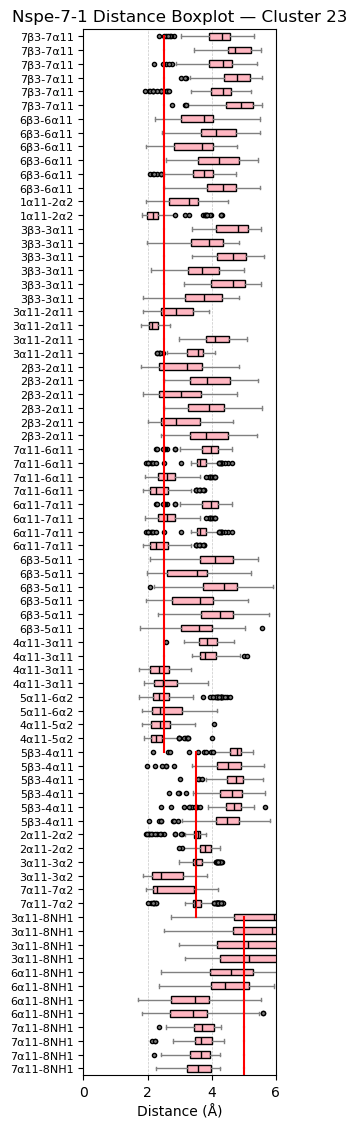

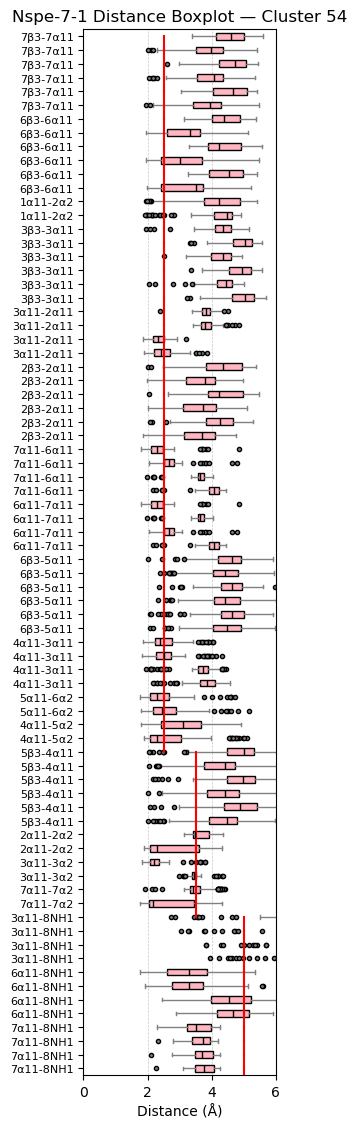

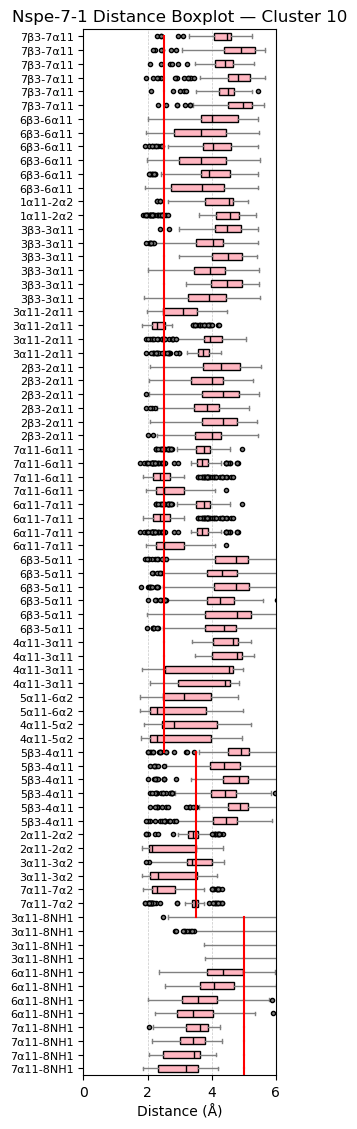

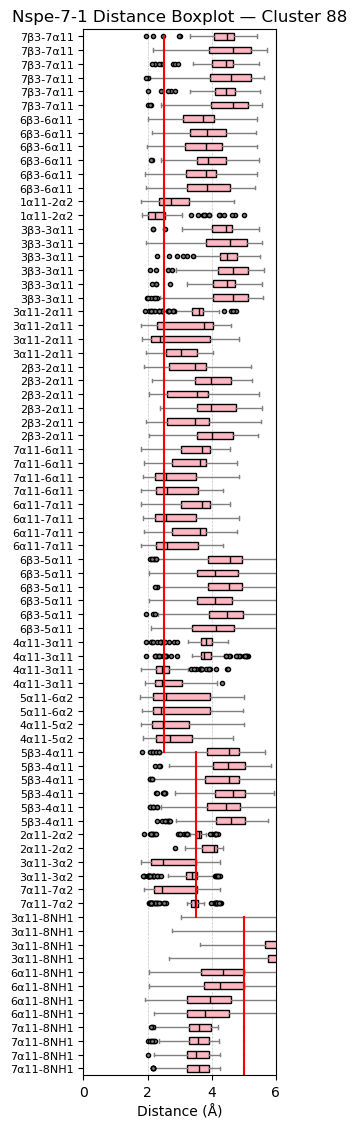

In [91]:
human_interpretable_label = True
grofile = "../nspe_7_1.amb2gmx/nspe_7_1_GMX.gro"
stride = 100

top_clusters = [label for label, _ in top]

for cluster in top_clusters:
    # Collect and subsample original frames
    all_frames = [dist_all[traj][frame] for traj, frame in top_cluster_frames[cluster]]
    all_frames = np.array(all_frames)[::stride]  # subsample every Nth frame

    # Plot boxplots for all 76 features
    plt.figure(figsize=(3, max(6, len(labels) * 0.15)))

    box = plt.boxplot(all_frames, vert=False, patch_artist=True,
                      boxprops=dict(facecolor='lightpink', color='black'),
                      medianprops=dict(color='black'),
                      whiskerprops=dict(color='gray'),
                      capprops=dict(color='gray'),
                      flierprops=dict(marker='o', markerfacecolor='gray', markersize=3, linestyle='none'))

    for yi, ti in enumerate(targets):
        plt.axvline(ti, ymin=(yi - 0.5)/len(labels), ymax=(yi + 0.5)/len(labels),
                    color='red', linewidth=1.5, linestyle='-')

    plt.yticks(np.arange(1, len(labels) + 1), labels, fontsize=8)
    plt.xlabel("Distance (Å)")
    plt.title(f"Nspe-7-1 Distance Boxplot — Cluster {cluster}")
    plt.xlim(0, 6)
    plt.grid(axis='x', linestyle='--', linewidth=0.5, alpha=0.7)
    plt.tight_layout()
    plt.show()


### Analysis Dihedral

In [92]:
def plot_dihedral_quadruplets(
    omega_all,
    residues_to_plot,
    states=range(16),
    use_latex=True,
    angles_to_plot=None
):
    """
    Plot selected dihedral angle pairs for each residue in each state.

    Parameters:
    -----------
    omega_all : np.ndarray
        Shape (n_states, n_frames, n_dihedrals)
    residues_to_plot : list of int
        Starting indices of each residue block (omega, phi, psi, chi1)
    states : list
        Indices of states to plot
    use_latex : bool
        Use LaTeX formatting for labels
    angles_to_plot : list of str
        Angle pairs to plot. Options:
            'omega_phi', 'omega_psi', 'phi_psi',
            'omega_chi1', 'phi_chi1', 'psi_chi1'
    """
    if angles_to_plot is None:
        angles_to_plot = ["omega_phi", "omega_psi", "phi_psi", "omega_chi1", "phi_chi1", "psi_chi1"]

    scatter_kws = dict(s=2, color='black', alpha=0.3)

    # Axis labels
    if use_latex:
        labels = {
            'phi': r'$\phi$',
            'psi': r'$\psi$',
            'omega': r'$\omega$',
            'chi1': r'$\chi_1$'
        }
    else:
        labels = {
            'phi': 'Phi',
            'psi': 'Psi',
            'omega': 'Omega',
            'chi1': 'Chi1'
        }

    def format_ax(ax, xlabel, ylabel):
        """Set axis limits and ticks based on dihedral type."""
        if labels['phi'] in xlabel:
            ax.set_xlim(-180, 180)
            ax.set_xticks(np.arange(-180, 181, 180))
        else:
            ax.set_xlim(-90, 270)
            ax.set_xticks(np.arange(-90, 271, 180))

        if labels['phi'] in ylabel:
            ax.set_ylim(-180, 180)
            ax.set_yticks(np.arange(-180, 181, 180))
        else:
            ax.set_ylim(-90, 270)
            ax.set_yticks(np.arange(-90, 271, 180))

        ax.set_xlabel(xlabel, labelpad=4)
        ax.set_ylabel(ylabel, labelpad=4)

    # Mapping from angle pair name to (x, y) keys and title suffix
    angle_plot_map = {
        'omega_phi':   ('phi',   'omega'),
        'omega_psi':   ('psi',   'omega'),
        'phi_psi':     ('psi',   'phi'),
        'omega_chi1':  ('chi1',  'omega'),
        'phi_chi1':    ('chi1',  'phi'),
        'psi_chi1':    ('chi1',  'psi'),
    }

    for state_idx in states:
        num_residues = len(residues_to_plot)
        num_pairs = len(angles_to_plot)
        nrows = num_residues
        ncols = num_pairs

        fig, axes = plt.subplots(nrows, ncols, figsize=(1.5 * ncols, 0.7 * nrows), sharex='col')
        axes = np.atleast_2d(axes)

        fig.suptitle(f'Nspe_7_1 — State {state_idx} REMD (Distances Restrainted OFF)', fontsize=10)

        for row_idx, residue in enumerate(residues_to_plot):
            omega = omega_all[state_idx, :, residue]
            phi   = omega_all[state_idx, :, residue + 1]
            psi   = omega_all[state_idx, :, residue + 2]
            chi1  = omega_all[state_idx, :, residue + 3]

            angle_data = {
                'omega': omega,
                'phi':   phi,
                'psi':   psi,
                'chi1':  chi1,
            }

            for col_idx, angle_pair in enumerate(angles_to_plot):
                x_key, y_key = angle_plot_map[angle_pair]
                x = angle_data[x_key]
                y = angle_data[y_key]
                ax = axes[row_idx, col_idx]
                ax.scatter(x, y, **scatter_kws)
                format_ax(ax, labels[x_key], labels[y_key])

                if row_idx == 0:
                    ax.set_title(f'{labels[y_key]} vs {labels[x_key]}')
                if col_idx == 0:
                    ax.set_ylabel(f'Res {residue//4}\n{labels[y_key]}')

        #fig.tight_layout()
        fig.subplots_adjust(wspace=0.5)  # adds horizontal space between columns
        plt.show()



Plotting Cluster 0 with 16 frames


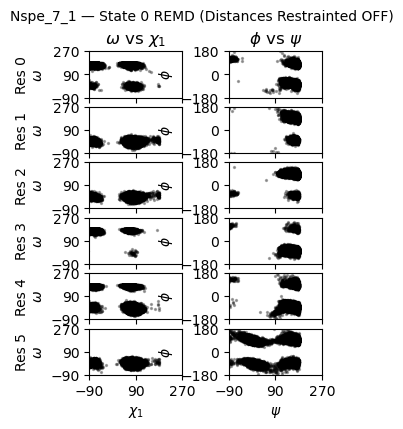

Plotting Cluster 95 with 16 frames


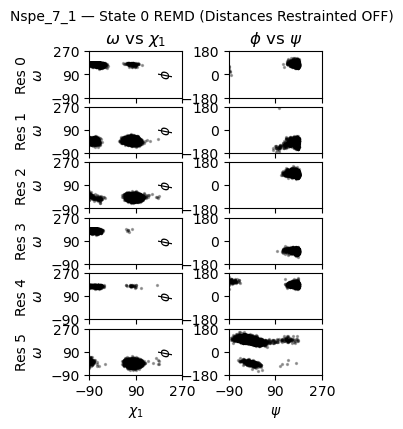

Plotting Cluster 23 with 16 frames


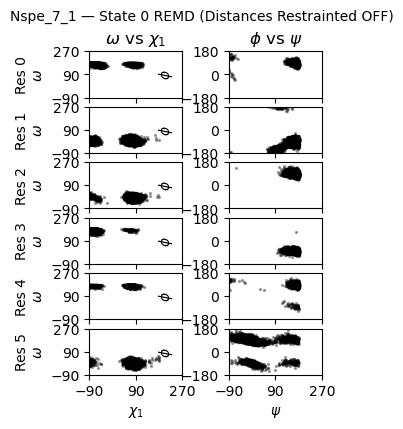

Plotting Cluster 54 with 16 frames


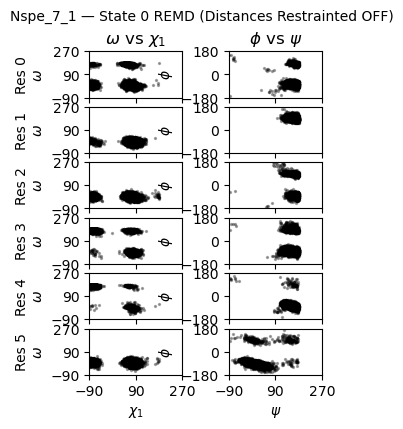

Plotting Cluster 10 with 16 frames


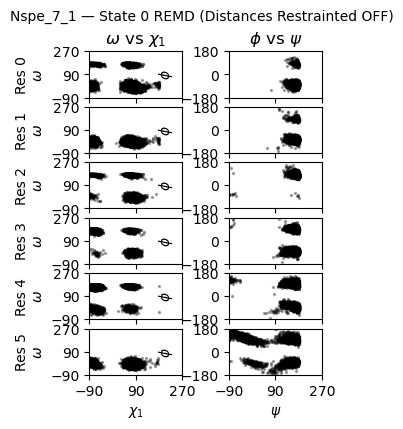

Plotting Cluster 88 with 16 frames


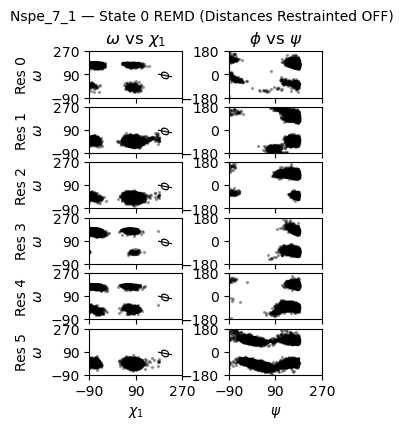

In [93]:
# Available options for angles_to_plot:

# "phi_psi"      # Plot ψ vs φ
# "omega_phi"    # Plot φ vs ω
# "omega_psi"    # Plot ψ vs ω
# "omega_chi1"   # Plot χ₁ vs ω
# "phi_chi1"     # Plot χ₁ vs φ
# "psi_chi1"     # Plot χ₁ vs ψ

residues_to_plot = np.arange(0, 24, 4).tolist()  # Modify if needed

angles_to_plot = ["omega_chi1", "phi_psi"]  # customize as needed

top_clusters = [label for label, _ in top]
stride = 1

for cluster in top_clusters:
    # Collect and subsample original frames
    all_frames = [omega_all[traj][frame] for traj, frame in top_cluster_frames[cluster]]
    all_frames = np.array(all_frames)[::stride]  # subsample every Nth frame
    
    omega_input = all_frames[np.newaxis, :, :]  # Shape (1, n_frames, 24)

    print(f"Plotting Cluster {cluster} with {omega_all.shape[0]} frames")

    plot_dihedral_quadruplets(
        omega_all=omega_input,
        residues_to_plot=residues_to_plot,
        states=[0],  # Only 1 cluster at a time
        use_latex=True,
        angles_to_plot=angles_to_plot
    )

## Sampling

In [95]:
# Load all trajectories and join
HREX_dir = '../traj_remd'
run_num = 10
state_num = 16 # lambda state 

HREX_list = [f"REMD_200ns_{i}" for i in range(1, run_num + 1)]


all_trajs = []
for state in tqdm(range(state_num)):
    trajs = []
    for HREX in HREX_list:
        HREX_path = f"{HREX_dir}/{HREX}"  
        xtcfile = f"{HREX_path}/state_{state}/HREMD.part0001_intact.xtc"
        grofile = f"../nspe_7_1.amb2gmx/nspe_7_1_GMX.gro"
        traj = md.load(xtcfile, top=grofile)
        trajs.append(traj)
    # Concatenate all trajectories
    concatenated_trajs = md.join(trajs)
    all_trajs.append(concatenated_trajs)



  0%|          | 0/16 [00:00<?, ?it/s]

In [94]:
# Define the directory path
directory = "sampling/"

# Check if the directory exists
if os.path.exists(directory):
    # Remove all contents of the directory
    shutil.rmtree(directory)
    # Recreate the empty directory
    os.makedirs(directory)
    print(f"All contents in '{directory}' have been cleared.")
else:
    # Create the directory if it does not exist
    os.makedirs(directory)
    print(f"Directory '{directory}' did not exist, so it has been created.")

All contents in 'sampling/' have been cleared.


In [96]:
sample_size = 5

for label in top_labels:
    traj_frame_pairs = top_cluster_frames[label]
    print('traj_frame_pairs', traj_frame_pairs.shape)
    # Randomly sample from frames in this cluster
    sample_n = min(sample_size, len(traj_frame_pairs))
    sampled_pairs = traj_frame_pairs[np.random.choice(len(traj_frame_pairs), sample_n, replace=False)]
    
    sampled_structures = []

    for traj_idx, frame_idx in sampled_pairs:
        traj = all_trajs[traj_idx][frame_idx]
        sampled_structures.append(traj)
    
    # Join and save sampled frames

    cluster_traj = md.join(sampled_structures)
    cluster_traj.save_xtc(f"sampling/sample_cluster{label}.xtc")
    cluster_traj.save_pdb(f"sampling/sample_cluster{label}.pdb")

    print(f"Saved {len(sampled_structures)} frames from cluster {label}")
    

traj_frame_pairs (89717, 2)
Saved 5 frames from cluster 0
traj_frame_pairs (10412, 2)
Saved 5 frames from cluster 95
traj_frame_pairs (12047, 2)
Saved 5 frames from cluster 23
traj_frame_pairs (11366, 2)
Saved 5 frames from cluster 54
traj_frame_pairs (17474, 2)
Saved 5 frames from cluster 10
traj_frame_pairs (13943, 2)
Saved 5 frames from cluster 88
